In [1]:
import json
METRICS = ['train_hard_loss', 'train_soft_loss', 'train_acc','test_loss', 'test_acc']
def get_metrics(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return tuple(data[metric] for metric in METRICS)

def populate_dict(path):
    return dict(zip(METRICS, get_metrics(path)))

In [2]:
import numpy as np
STDS = [f'{n:.2f}' for n in np.arange(0, 4, 0.333)]
TARGETS = ['both', 'student', 'teacher']
RUNS = 2

things = {}
for target in TARGETS:
    things[target] = {}
    for std in STDS:
        things[target][std] = {}
        for run in range(RUNS):
            path = f"noise-injection-experiments/{target}/std{std}/{run}/metrics.json"
            things[target][std][run] = populate_dict(path)


In [3]:
def stack_arrays(d, metric):
    arrays = [np.array(d[run][metric]) for run in range(RUNS)]
    stacked = np.stack(arrays)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0, ddof=1)

thing_p = {}
for target in TARGETS:
    thing_p[target] = {}
    for std in STDS:
        thing_p[target][std] = {}
        for metric in METRICS:
            mean, stdd = stack_arrays(things[target][std], metric)
            thing_p[target][std] = {'mean': mean, 'std': stdd}
    
thing_pp = {}
for target in TARGETS:
    thing_pp[target] = {}
    thing_pp[target]['std'] = [std for std in STDS]
    thing_pp[target]['max'] = [thing_p[target][std]['mean'].max() for std in STDS]
        

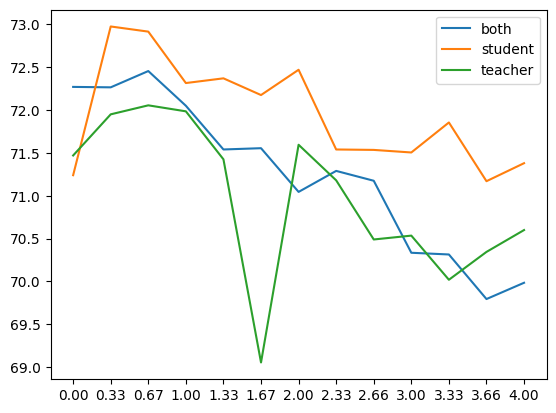

In [4]:
import matplotlib.pyplot as plt
for target in TARGETS:
    plt.plot(thing_pp[target]['std'], thing_pp[target]['max'], label=target)
plt.legend()
plt.show()

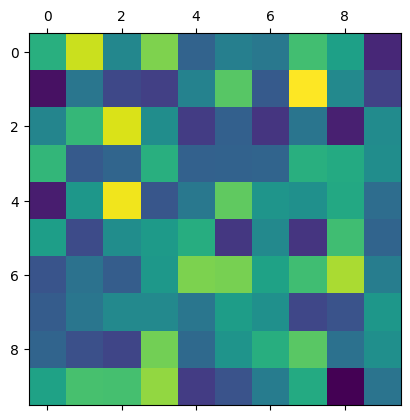

In [5]:
import torch
noise = torch.normal(mean=0.0, std=1, size=(10,10))
plt.matshow(noise)